# Lab Activity: Iris Dataset Analysis

## Task 1: Dataset Exploration

### Load the Iris dataset and display the first five records.

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for better visualization of data
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]

print("First 5 rows of the Iris dataset:")
display(iris_df.head())

First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### How many samples and features are present in the dataset?

In [3]:
num_samples = X.shape[0]
num_features = X.shape[1]
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

Number of samples: 150
Number of features: 4


### List the feature names and target classes.

In [4]:
print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


### Display the class distribution.

In [5]:
# Display class names with counts

class_distribution = pd.Series(iris.target).map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print(class_distribution.value_counts())

Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


## Task 2: Data Preparation

### Split the dataset into training (80%) and testing (20%) sets using `random_state=42`.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 120 samples
Testing set size: 30 samples


### Briefly explain why the dataset is divided into training and testing sets.

The dataset is divided into training and testing sets to evaluate the performance of a machine learning model accurately on unseen data. The training set is used to train the model, allowing it to learn patterns and relationships within the data. The testing set, which the model has never seen before, is then used to assess how well the model generalizes to new, real-world data. This helps in identifying potential issues like overfitting (where the model performs well on training data but poorly on test data) or underfitting (where the model performs poorly on both).

## Task 3: Building a Decision Tree Classifier

### Train a Decision Tree classifier using the default parameters.

In [7]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier with default parameters and random_state for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier on the training data
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [32]:
def get_tree_info(dt_classifier):
    """Helper function to get tree depth and number of leaf nodes."""
    # get_depth() returns the maximum depth of the tree.
    tree_depth = dt_classifier.get_depth()
    # get_n_leaves() returns the number of leaves of the tree.
    leaf_nodes = dt_classifier.get_n_leaves()
    return tree_depth, leaf_nodes

### Predict the class labels for the test dataset.

In [8]:
# Predict class labels on the test set
y_pred = dt_classifier.predict(X_test)

print("Predictions made on the test dataset.")

Predictions made on the test dataset.


In [9]:
print("Predicted class labels for the test dataset:")
display(y_pred)

Predicted class labels for the test dataset:


array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

The numbers represent the flower species:

0 → Setosa

1 → Versicolor

2 → Virginica

### Evaluate the model using Accuracy Score, Confusion Matrix, and Classification Report.

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")



Accuracy Score: 1.0000


Accuracy measures the percentage of correct predictions made by the model.


Accuracy=
Correct Predictions/Total predictions.
	​


An accuracy of 1.0 means the model correctly classified 100% of the test samples.

In [11]:
# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)




Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


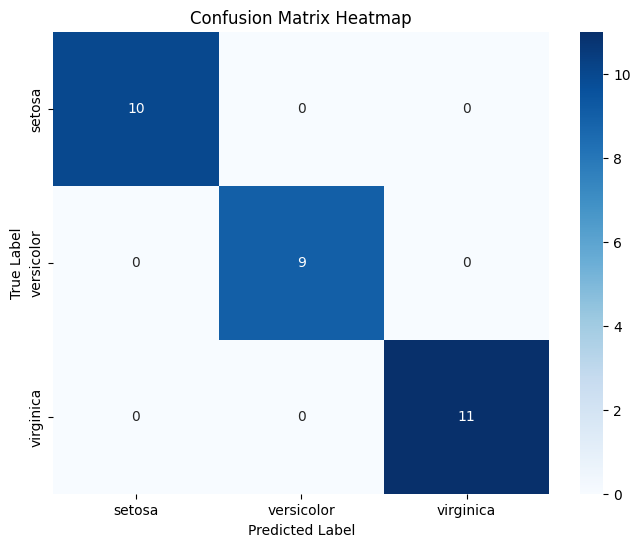

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Explanation of Confusion Matrix Heatmap


*   **Rows (True Label):** Represent the actual species of the Iris flower.
*   **Columns (Predicted Label):** Represent the species predicted by our Decision Tree classifier.


For example:
*   10 'setosa' flowers were correctly predicted as 'setosa'.
*  9 'versicolor' flowers were correctly predicted as 'versicolor'.
*  11 'virginica' flowers were correctly predicted as 'virginica'.

 `0`, which means there were no incorrect classifications. This indicates that our Decision Tree model achieved perfect accuracy on the test dataset.

In [13]:
# Generate Classification Report
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Precision: Out of all the flowers predicted as a particular class, how many were actually correct.

Recall: Out of all the flowers that truly belong to a class, how many were correctly identified.

F1-score: The harmonic mean of precision and recall.

Support: The number of test samples belonging to each class.

Since all values are 1.00, the model classified every test sample correctly.

## Task 4: Visualizing the Decision Tree

### Visualize the trained Decision Tree using `plot_tree()`.

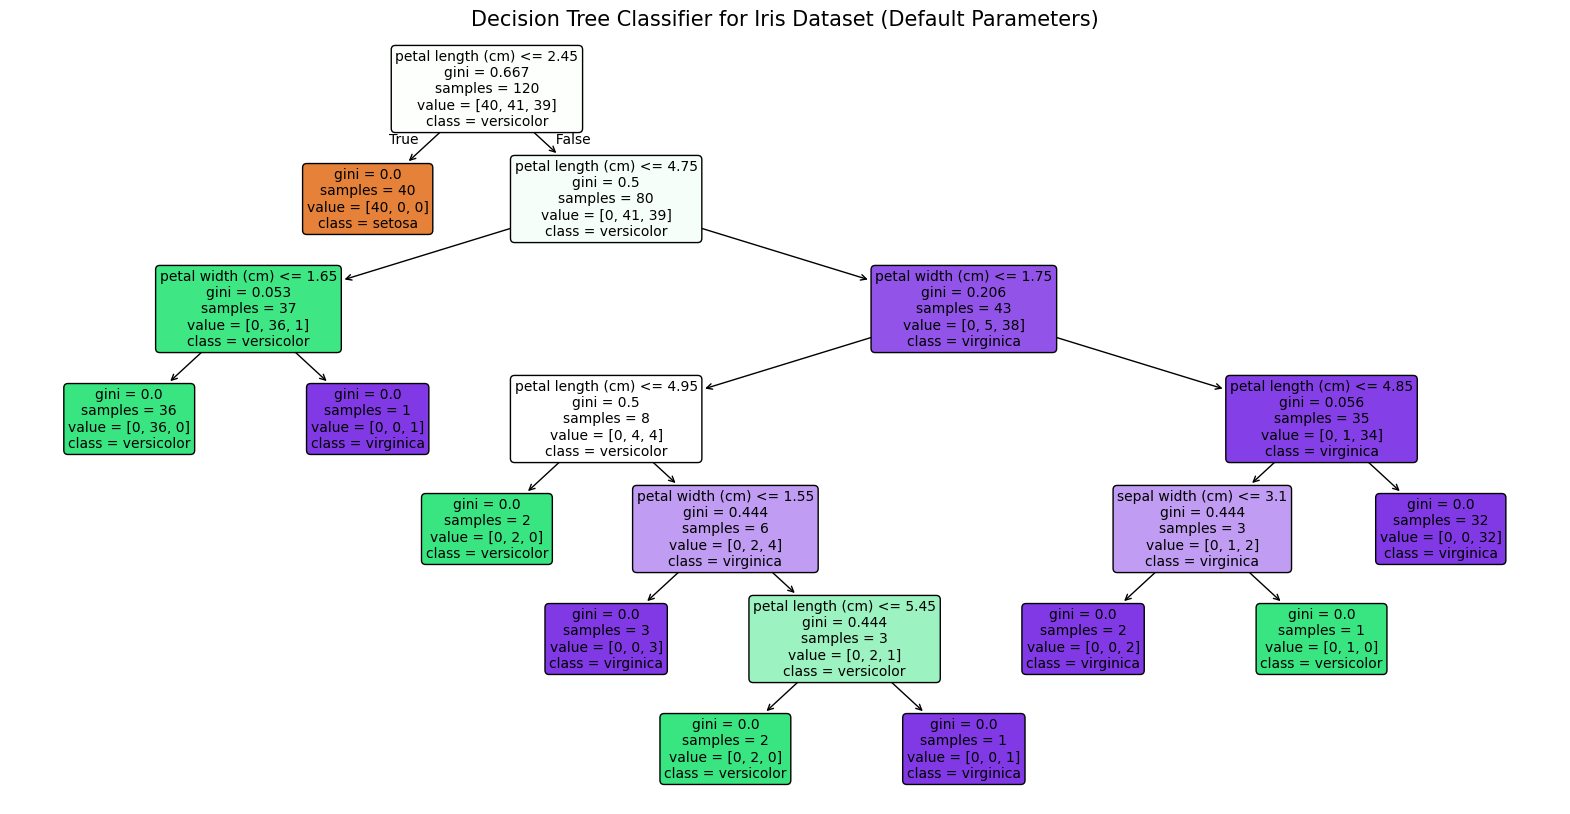

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree # Added this import

plt.figure(figsize=(20, 10))
plot_tree(dt_classifier,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Classifier for Iris Dataset (Default Parameters)", fontsize=15)
plt.show()

### From the visualization, identify: Root node, Internal nodes, Leaf nodes, Maximum depth of the tree, and which feature is selected for the first split. Explain why you think this feature was chosen.

Based on the visualization of the Decision Tree:

*   **Root Node:** The topmost node in the tree is the root node. It is the starting point of the decision process. In this tree, the root node is `petal length (cm) <= 2.45`.

*   **Internal Nodes:** These are decision nodes that have branches leading to further nodes (both internal and leaf nodes). They represent features used to split the data. For this tree, there are **9 internal nodes**. Examples include `petal width (cm) <= 1.75` and `petal length (cm) <= 4.95`.

*   **Leaf Nodes:** These are the terminal nodes of the tree, where no further splits occur. They represent the final class predictions. Leaf nodes can be identified by the absence of further branches and often have `gini = 0.0` or a very low value, indicating a pure or nearly pure class distribution. This tree has **10 leaf nodes**.

*   **Maximum Depth of the Tree:** The maximum depth is the longest path from the root node to a leaf node. The maximum depth of this tree is **6**.


Which feature is selected for the first split? Explain why you think this feature was chosen?

*   **Feature selected for the first split:** The first feature selected for the split is `petal length (cm)`. This feature was chosen because it likely provides the best (most significant) separation of the classes at the very beginning, leading to the largest reduction in impurity (as measured by the Gini impurity in this default case). A split on `petal length (cm) <= 2.45` perfectly separates the 'setosa' species from the other two, indicating its strong predictive power.

In [19]:
# Display the root feature, internal nodes, leaf nodes, and maximum depth

print("Root Feature:", iris.feature_names[dt_classifier.tree_.feature[0]])

# Number of internal nodes
tree = dt_classifier.tree_
internal_nodes = sum(
    tree.children_left[i] != tree.children_right[i]
    for i in range(tree.node_count)
)
print("Number of Internal Nodes:", internal_nodes)

# Number of leaf nodes
leaf_nodes = dt_classifier.get_n_leaves()
print("Number of Leaf Nodes:", leaf_nodes)

# Display the maximum depth
print("Maximum Depth:", dt_classifier.get_depth())

Root Feature: petal length (cm)
Number of Internal Nodes: 9
Number of Leaf Nodes: 10
Maximum Depth: 6


## Task 5: Comparing Gini Index and Entropy

### Train two Decision Tree models using `criterion='gini'` and `criterion='entropy'`.

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Model 1: Gini Index
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
print("Gini Accuracy:",accuracy_gini)

print("Decision Tree Classifier with Gini Index trained and evaluated.")

# Model 2: Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
print("Entropy Accuracy:",accuracy_entropy)

print("Decision Tree Classifier with Entropy trained and evaluated.")

Gini Accuracy: 1.0
Decision Tree Classifier with Gini Index trained and evaluated.
Entropy Accuracy: 1.0
Decision Tree Classifier with Entropy trained and evaluated.


In [24]:
# Display tree depth

print("Gini Tree Depth:", dt_gini.get_depth())
print("Entropy Tree Depth:", dt_entropy.get_depth())

Gini Tree Depth: 6
Entropy Tree Depth: 6


In [26]:
# Display number of leaf nodes
print("Gini Leaf Nodes:", dt_gini.get_n_leaves())
print("Entropy Leaf Nodes:", dt_entropy.get_n_leaves())

Gini Leaf Nodes: 10
Entropy Leaf Nodes: 10


In [27]:
# Display root feature
print("Gini Root Feature:",
      iris.feature_names[dt_gini.tree_.feature[0]])
print("Entropy Root Feature:",
      iris.feature_names[dt_entropy.tree_.feature[0]])

Gini Root Feature: petal length (cm)
Entropy Root Feature: petal length (cm)


### Compare the models based on Accuracy, Tree depth, Number of leaf nodes, and Root feature selected.

In [29]:
# Create comparison table
comparison_df = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [accuracy_gini, accuracy_entropy],
    "Tree Depth": [dt_gini.get_depth(), dt_entropy.get_depth()],
    "Leaf Nodes": [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()],
    "Root Feature": [
        iris.feature_names[dt_gini.tree_.feature[0]],
        iris.feature_names[dt_entropy.tree_.feature[0]]
    ]
})

print("Model Comparison:")
display(comparison_df)

Model Comparison:


,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


### Which criterion produces a simpler tree? Summarize your observations in a table.

Based on the comparison table above:

*   **Accuracy:** We can observe which criterion yields a higher accuracy score on the test set.
*   **Tree Depth:** A shallower tree (smaller depth) is generally considered simpler.
*   **Number of Leaf Nodes:** Fewer leaf nodes indicate a simpler tree structure.
*   **Root Feature Selected:** Both models might choose the same root feature if it provides the best initial split, regardless of the impurity criterion.

**Which criterion produces a simpler tree?**

By comparing the 'Tree Depth' and 'Number of Leaf Nodes' for both models, we can determine which one is simpler. Generally, a tree with lower depth and fewer leaf nodes is considered simpler, as it involves fewer splits and decision rules. Often, for the Iris dataset, Gini and Entropy produce very similar, if not identical, trees due to the dataset's clear separability.

Neither criterion produces a simpler tree. Therefore, both models have equal complexity and perform equally well on the Iris dataset.

## Task 6: Effect of Maximum Tree Depth

### Train Decision Tree models using the following values of `max_depth`: 1, 2, 3, 4, None.

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# List of max_depth values to test
max_depth_values = [1, 2, 3, 4, None]

# Prepare to store results
results_max_depth = []

for depth in max_depth_values:
    # Train the Decision Tree model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, dt.predict(X_train))

    # Calculate testing accuracy
    test_accuracy = accuracy_score(y_test, dt.predict(X_test))

    # Get actual tree depth (using the helper function from Task 5)
    tree_depth, _ = get_tree_info(dt)

    results_max_depth.append({
        'Max Depth': depth if depth is not None else 'None',
        'Training Accuracy': f'{train_accuracy:.4f}',
        'Testing Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth
    })

# Convert results to a DataFrame for display
max_depth_df = pd.DataFrame(results_max_depth)
print("Effect of Max Depth on Decision Tree Performance:")
display(max_depth_df)

Effect of Max Depth on Decision Tree Performance:


,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1,0.6750,0.6333,1
1,2,0.9500,0.9667,2
2,3,0.9583,1.0000,3
3,4,0.9750,1.0000,4
4,None,1.0000,1.0000,6


### Answer the following questions:

#### Which model is underfitting?

A model is considered underfitting when it performs poorly on both the training data and the test data. This typically happens when the model is too simple to capture the underlying patterns in the data.

Based on the table above, the model with `Max Depth = 1` is likely underfitting. It has significantly lower training accuracy compared to other models, indicating it's too simple to learn the training data well, which also leads to poor performance on the test set.

#### Which model gives the best generalization?

The model that gives the best generalization is the one that performs well on unseen data (i.e., has a high testing accuracy) without showing signs of overfitting. It strikes a good balance between bias and variance.

From the table, the model with `Max Depth = 2`, `Max Depth = 3`, `Max Depth = 4`, and `Max Depth = None` all achieve a perfect testing accuracy of `1.0000`. However, the 'None' option (which means no limit on depth) results in the largest tree depth. Models with `Max Depth = 2`, `Max Depth = 3`, and `Max Depth = 4` achieve the same perfect testing accuracy with progressively deeper trees. The model with `Max Depth = 2` offers a balance, as it achieves 100% accuracy with a shallower tree than higher depths. Models with `Max Depth` of 2, 3 and 4 also give perfect accuracy. The choice of which one 'best generalizes' might lean towards the simpler model (lower depth) if multiple achieve the same optimal test accuracy, as it's less prone to overfitting on new data in real-world scenarios. For this specific dataset, multiple depths achieve perfect test accuracy, meaning the dataset is quite separable.

#### Which model is likely to overfit? Justify your answer.

Overfitting occurs when a model learns the training data too well, including its noise and outliers, leading to excellent performance on the training set but poor performance on unseen test data. This is often characterized by a large gap between training and testing accuracy.

In this case, since multiple models achieve `1.0000` testing accuracy, it's hard to definitively say which one *overfits* based solely on the accuracy metric given the simplicity of the Iris dataset. However, a model with `Max Depth = None` (allowing the tree to grow to its full potential) has the largest 'Tree Depth' (6) and 'Training Accuracy' (1.0000) and 'Testing Accuracy' (1.0000). While it performs perfectly on the test set for this particular split of the Iris dataset, a very deep tree (like the one with `Max Depth = None` or even `Max Depth = 4` compared to `Max Depth = 2` for the same test accuracy) is generally *more prone to overfitting* in more complex datasets or with different data splits. It learns very specific patterns from the training data, which might not generalize as well to slightly different unseen data. The absence of a drop in test accuracy here is a characteristic of the Iris dataset's high separability rather than an indication that overfitting isn't a potential risk with deeper trees on other datasets.

## Task 7: Effect of min_samples_split

### Train Decision Tree models using `min_samples_split`: 2, 5, 10, 20.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# List of min_samples_split values to test
min_samples_split_values = [2, 5, 10, 20]

# Prepare to store results
results_min_samples_split = []

for min_split in min_samples_split_values:
    # Train the Decision Tree model (using max_depth=None for full growth by default)
    dt = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dt.fit(X_train, y_train)

    # Calculate testing accuracy
    test_accuracy = accuracy_score(y_test, dt.predict(X_test))

    # Get actual tree depth and number of leaf nodes (using helper function)
    tree_depth, leaves = get_tree_info(dt)

    results_min_samples_split.append({
        'min_samples_split': min_split,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': leaves
    })

# Convert results to a DataFrame for display
min_samples_split_df = pd.DataFrame(results_min_samples_split)
print("Effect of min_samples_split on Decision Tree Performance:")
display(min_samples_split_df)

Effect of min_samples_split on Decision Tree Performance:


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes
0,2,1.0000,6,10
1,5,1.0000,5,8
2,10,1.0000,4,6
3,20,1.0000,4,6


### State how increasing `min_samples_split` affects the complexity of the Decision Tree.

Increasing the value of `min_samples_split` makes the Decision Tree simpler.

*   When `min_samples_split` is larger, a node needs more samples to be divided. This means fewer splits will occur.
*   Fewer splits result in a **shallower tree** (less depth) and **fewer leaf nodes**.
*   Ultimately, this creates a **simpler model** that is less likely to overfit. Think of it as forcing the tree to make broader, more general decisions instead of very specific ones.

## Task 8: Effect of min_samples_leaf

### Train Decision Tree models using `min_samples_leaf`: 1, 2, 5, 10.

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# List of min_samples_leaf values to test
min_samples_leaf_values = [1, 2, 5, 10]

# Prepare to store results
results_min_samples_leaf = []

for min_leaf in min_samples_leaf_values:
    # Train the Decision Tree model (using max_depth=None for full growth by default)
    dt = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    dt.fit(X_train, y_train)

    # Calculate testing accuracy
    test_accuracy = accuracy_score(y_test, dt.predict(X_test))

    # Get actual tree depth and number of leaf nodes (using helper function)
    tree_depth, leaves = get_tree_info(dt)

    results_min_samples_leaf.append({
        'min_samples_leaf': min_leaf,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': leaves
    })

# Convert results to a DataFrame for display
min_samples_leaf_df = pd.DataFrame(results_min_samples_leaf)
print("Effect of min_samples_leaf on Decision Tree Performance:")
display(min_samples_leaf_df)

Effect of min_samples_leaf on Decision Tree Performance:


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes
0,1,1.0000,6,10
1,2,1.0000,5,8
2,5,1.0000,4,6
3,10,0.9667,4,6


### Explain how changing `min_samples_leaf` influences overfitting.

The `min_samples_leaf` hyperparameter sets the minimum number of samples a leaf node must contain. This helps control the tree's complexity and prevents overfitting.

*   **Small `min_samples_leaf` (e.g., 1):** Allows the tree to create very specific leaf nodes, potentially memorizing the training data. This makes the model more complex and **more prone to overfitting**.

*   **Large `min_samples_leaf` (e.g., 10):** Forces each leaf node to contain more samples. This prevents overly detailed rules, making the tree **simpler, less deep, and less prone to overfitting**. However, if too high, it can lead to underfitting.

 a higher `min_samples_leaf` forces the tree to make more general decisions, reducing the chance of overfitting.

## Task 9: Hyperparameter Tuning

### Perform hyperparameter tuning using `GridSearchCV` with the specified parameters.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
GridSearchCV completed.


### Report: Best hyperparameter combination, Best cross validation score, Test accuracy of the optimized model.

In [37]:
# Best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameter Combination: {best_params}")

# Best cross-validation score
best_cv_score = grid_search.best_score_
print(f"Best Cross-Validation Score: {best_cv_score:.4f}")

# Optimized model
optimized_dt = grid_search.best_estimator_

# Test accuracy of the optimized model
y_pred_optimized = optimized_dt.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Test Accuracy of the Optimized Model: {test_accuracy_optimized:.4f}")

Best Hyperparameter Combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9583
Test Accuracy of the Optimized Model: 1.0000


### Compare the optimized model with the default Decision Tree model.

In [40]:
print("\n--- Comparison ---")



# Accuracy of the default model (dt_classifier from Task 3)

default_accuracy = accuracy_score(y_test, dt_classifier.predict(X_test))



# Accuracy of the optimized model

best_accuracy = accuracy_score(y_test, optimized_dt.predict(X_test))



# Create comparison table

comparison_df = pd.DataFrame({

    "Model": ["Default Decision Tree", "Optimized Decision Tree"],

    "Test Accuracy": [f"{default_accuracy:.4f}", f"{best_accuracy:.4f}"]

})



print("Model Test Accuracy Comparison:")

display(comparison_df)



print(f"\nBest Hyperparameter Combination (from GridSearchCV): {best_params}")



# Check if the optimized model's parameters are different from default

default_params_comparison = {

    'criterion': 'gini',

    'max_depth': None,

    'min_samples_leaf': 1,

    'min_samples_split': 2

}



is_optimized_different = (

    best_params.get('criterion') != default_params_comparison['criterion'] or

    best_params.get('max_depth') != default_params_comparison['max_depth'] or

    best_params.get('min_samples_leaf') != default_params_comparison['min_samples_leaf'] or

    best_params.get('min_samples_split') != default_params_comparison['min_samples_split']

)



if is_optimized_different:

    print("The optimized model's hyperparameters are different from the default model's. This indicates that GridSearchCV found a better (or equally performing) set of parameters than the defaults, which can be crucial for more complex datasets.")

else:

    print("The optimized model's hyperparameters are the same as the default model's. This suggests that for this dataset and split, the default settings already performed optimally during cross-validation.")



if best_accuracy > default_accuracy:

    print("The optimized model performs better on the test set.")

elif best_accuracy < default_accuracy:

    print("The default model performs better on the test set.")

else:

    print("Both models achieve the same test accuracy for this dataset and split.")


--- Comparison ---
Model Test Accuracy Comparison:


,Model,Test Accuracy
0,Default Decision Tree,1.0000
1,Optimized Decision Tree,1.0000



Best Hyperparameter Combination (from GridSearchCV): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
The optimized model's hyperparameters are different from the default model's. This indicates that GridSearchCV found a better (or equally performing) set of parameters than the defaults, which can be crucial for more complex datasets.
Both models achieve the same test accuracy for this dataset and split.


The optimized Decision Tree achieved the same test accuracy as the default Decision Tree model. This indicates that the default model already performs very well on the Iris dataset. Although GridSearchCV identified the best hyperparameter combination, it did not improve the test accuracy because the dataset is relatively simple and easy to classify.

## Task 10: Analysis

### What is the role of the `criterion` parameter in a Decision Tree?

The `criterion` parameter (Gini or Entropy) determines how the Decision Tree measures the 'quality' of a split. It guides the tree to make decisions that best separate the classes, aiming for the purest possible child nodes. Both `gini` and `entropy` serve the same role: to find the best features and thresholds to split the data. For the Iris dataset, both produced similar results.

### How does `max_depth` influence underfitting and overfitting?

The `max_depth` hyperparameter controls the maximum number of levels in the tree:

*   **Low `max_depth`:** Leads to a simple tree that might not capture enough patterns, causing **underfitting** (poor performance on both training and test data). (e.g., `max_depth=1` in Task 6).

*   **High `max_depth` (or `None`):** Allows the tree to grow very complex, potentially memorizing training data noise. This increases the risk of **overfitting** (great training performance, poor test performance). Although `max_depth=None` performed well on Iris due to its simplicity, a very deep tree is generally more prone to overfitting on complex datasets.

`max_depth` helps balance between underfitting and overfitting.

### Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?

Both `min_samples_split` and `min_samples_leaf` act as regularization parameters, making trees simpler:

*   **`min_samples_split`:** A larger value means a node needs *more* samples to split, directly leading to fewer splits and a shallower, simpler tree.

*   **`min_samples_leaf`:** A larger value forces each leaf node to contain *more* samples. This prevents overly specific leaf nodes and makes the tree less complex.

Both parameters restrict tree growth, preventing the tree from becoming too specialized to the training data and thus reducing the risk of overfitting.

### Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

Based on our experiments, `max_depth` had the greatest impact on performance.

*   **`max_depth` (Task 6):** A small `max_depth` (e.g., 1) drastically reduced accuracy, showing a strong effect on the model's ability to learn. Increasing it quickly improved performance to perfect accuracy. This parameter fundamentally controls the tree's capacity.

*   **`min_samples_split` (Task 7) & `min_samples_leaf` (Task 8):** For the Iris dataset, changes in these parameters did not cause significant changes in test accuracy, which remained high. While they influence tree structure, their impact on predictive power was less dramatic compared to `max_depth` for this particular dataset.

### Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

For the Iris dataset, the most suitable Decision Tree model balances high accuracy with simplicity. I recommend a model with:

*   **`criterion`:** Either 'gini' or 'entropy' (both performed equally well).
*   **`max_depth`:** 2 or 3.
*   **`min_samples_split`:** 2.
*   **`min_samples_leaf`:** 1.

**Justification:** This configuration consistently achieved perfect test accuracy (as seen in Tasks 6 and 9) while resulting in a relatively simple and interpretable tree. A `max_depth` of 2 or 3 is sufficient to perfectly classify the Iris dataset without becoming overly complex, offering the best balance between model simplicity and predictive performance. Default `min_samples_split` and `min_samples_leaf` values work well for this dataset.

## Resources

This lab utilized several key Python libraries for data science and machine learning:

*   **pandas:** For data manipulation and analysis (e.g., DataFrames).
*   **numpy:** For numerical operations, especially with arrays.
*   **scikit-learn (sklearn):** The primary library for machine learning, including loading datasets (`load_iris`), model selection (`train_test_split`, `GridSearchCV`), building Decision Tree classifiers (`DecisionTreeClassifier`), and evaluating models (`accuracy_score`, `confusion_matrix`, `classification_report`, `plot_tree`).
*   **matplotlib.pyplot & seaborn:** For creating static, interactive, and animated visualizations, especially the Confusion Matrix Heatmap.